In [259]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [260]:
# 1

a = np.linspace(start=1, stop=100, num=100)
b = np.logspace(0, stop=np.log(100), num=100)

def calculate_returns(x):
    return np.concatenate([[0], (x[1:] - x[:-1]) / x[:-1]])


def calculate_returns_for(x):
    n = len(x)
    returns = np.zeros(n)
    for t in range(1, n):
        returns[t] = (x[t] - x[t-1]) / x[t-1]
    return returns
        

print(calculate_returns(a))
print(calculate_returns(b))

[0.         1.         0.5        0.33333333 0.25       0.2
 0.16666667 0.14285714 0.125      0.11111111 0.1        0.09090909
 0.08333333 0.07692308 0.07142857 0.06666667 0.0625     0.05882353
 0.05555556 0.05263158 0.05       0.04761905 0.04545455 0.04347826
 0.04166667 0.04       0.03846154 0.03703704 0.03571429 0.03448276
 0.03333333 0.03225806 0.03125    0.03030303 0.02941176 0.02857143
 0.02777778 0.02702703 0.02631579 0.02564103 0.025      0.02439024
 0.02380952 0.02325581 0.02272727 0.02222222 0.02173913 0.0212766
 0.02083333 0.02040816 0.02       0.01960784 0.01923077 0.01886792
 0.01851852 0.01818182 0.01785714 0.01754386 0.01724138 0.01694915
 0.01666667 0.01639344 0.01612903 0.01587302 0.015625   0.01538462
 0.01515152 0.01492537 0.01470588 0.01449275 0.01428571 0.01408451
 0.01388889 0.01369863 0.01351351 0.01333333 0.01315789 0.01298701
 0.01282051 0.01265823 0.0125     0.01234568 0.01219512 0.01204819
 0.01190476 0.01176471 0.01162791 0.01149425 0.01136364 0.01123596
 0.

In [261]:
# 2

n_list = [100, 500, 1000, 2000, 5000]
k_list = [5, 10, 20, 50, 100]

    
def create_weighted_scores(n, k):
    scores = np.random.randint(0, 21, size=(n, k))
    w = np.random.random(k)
    w = w / np.sum(w)
    
    return scores, w


def calculate_weighted_average_numpy(scores, w):
    return scores@w


def calculate_weighted_average_python(scores, w):
    n, k = scores.shape
    result = np.zeros(n)
    for i in range(n):
        total = 0
        for j in range(k):
            total += scores[i, j] * w[j]
        result[i] = total
    return result


def benchmark(n_list, k_list):
    numpy_times = []
    python_times  = []
    
    for n in n_list:
        for k in k_list:
            
            # create data
            scores, w = create_weighted_scores(n, k)
            
            # with numpy:
            start = time.time()
            calculate_weighted_average_numpy(scores, w)
            numpy_time = time.time() - start
            numpy_times.append((n, k, numpy_time))
            
            # with loop:
            start = time.time()
            calculate_weighted_average_python(scores, w)
            loop_times = time.time() - start
            python_times.append((n, k, loop_times))
             
             
    return numpy_times, python_times


n_values = [10, 50, 100, 200, 500, 1000, 2000, 3000, 5000, 8000, 10000]
k_values = [2, 5, 10, 20, 30, 50, 75, 100, 150, 200]

numpy_times, python_times = benchmark(n_values, k_values)


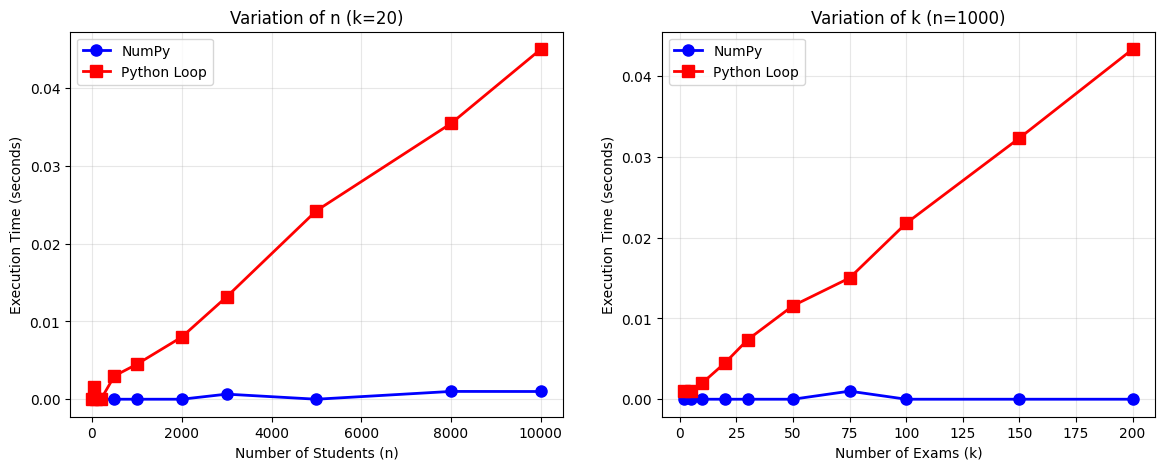

In [262]:
# Plot two side-by-side graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Variation of n (with k fixed)
k_fixed = 20
n_vals = []
numpy_vals_k20 = []
python_vals_k20 = []

for n, k, t in numpy_times:
    if k == k_fixed:
        n_vals.append(n)
        numpy_vals_k20.append(t)

for n, k, t in python_times:
    if k == k_fixed:
        python_vals_k20.append(t)

ax1.plot(n_vals, numpy_vals_k20, 'bo-', label='NumPy', linewidth=2, markersize=8)
ax1.plot(n_vals, python_vals_k20, 'rs-', label='Python Loop', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Students (n)')
ax1.set_ylabel('Execution Time (seconds)')
ax1.set_title(f'Variation of n (k={k_fixed})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graph 2: Variation of k (with n fixed)
n_fixed = 1000
k_vals = []
numpy_vals_n1000 = []
python_vals_n1000 = []

for n, k, t in numpy_times:
    if n == n_fixed:
        k_vals.append(k)
        numpy_vals_n1000.append(t)

for n, k, t in python_times:
    if n == n_fixed:
        python_vals_n1000.append(t)

ax2.plot(k_vals, numpy_vals_n1000, 'bo-', label='NumPy', linewidth=2, markersize=8)
ax2.plot(k_vals, python_vals_n1000, 'rs-', label='Python Loop', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Exams (k)')
ax2.set_ylabel('Execution Time (seconds)')
ax2.set_title(f'Variation of k (n={n_fixed})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

In [263]:
# 3


rainfall = np.random.exponential(scale=5, size=(50, 365))
rainfall = rainfall * 0.1

nan_mask = np.random.random((50, 365)) < 0.1
rainfall[nan_mask] = np.nan

def find_day_for_150(city_rain):
    total = 0
    for day in range(len(city_rain)):
        if not np.isnan(city_rain[day]):
            total += city_rain[day]
            if total >= 150:
                return day + 1
    return np.nan
            
def monthly_rain(city_rain):
    monthly = []
    for month in range(12):
        start = month*30
        end = min((month+1)*30, len(city_rain))
        month_data = city_rain[start:end]
        month_data_clean = month_data[~np.isnan(month_data)]
        monthly.append(np.sum(month_data_clean) if len(month_data_clean) > 0 else 0)
    return np.array(monthly)

days_to_150 = []
for city in range(50):
    day = find_day_for_150(rainfall[city])
    days_to_150.append(day)
    
print(days_to_150)


wettest_months = []
monthly_totals = np.zeros((50, 12))
for city in range(50):
    monthly = monthly_rain(rainfall[city])
    monthly_totals[city] = monthly
    wettest_month = np.argmax(monthly)
    wettest_months.append(wettest_month)
    
print(monthly_totals[:3])
print(wettest_months)


[354, 361, 328, 324, 341, nan, 337, nan, 337, nan, 357, 320, 291, 320, 359, 316, 323, nan, 307, 334, 360, 335, 346, 321, 329, 339, 326, 348, 308, 345, 342, 322, 316, 348, 335, 319, 324, 342, 298, 347, 337, 316, 304, 318, 303, 360, 360, 319, 333, 325]
[[13.23595964 15.69895834  9.50655553 11.79080253 10.48404283 15.46319542
  14.65584696 13.62126884  8.6688934  15.58425865 12.30119624 12.25473515]
 [13.07939567  7.02075607  9.72449973 11.79627838 14.94761078 15.31001108
  12.81983924  9.42076538 15.56813157 14.86200425 12.41265632 12.47666301]
 [12.20029756 14.0156377  16.06256974  9.9107235  14.86931241 12.02996491
  14.07512898 18.33482831 11.63425041 14.65146115 13.45213965  9.40061359]]
[1, 8, 7, 9, 5, 5, 5, 1, 8, 10, 11, 10, 0, 0, 7, 0, 0, 7, 5, 7, 1, 7, 11, 1, 7, 11, 6, 11, 3, 5, 7, 2, 0, 11, 7, 3, 3, 1, 1, 11, 6, 6, 0, 8, 2, 5, 11, 1, 0, 5]


[[ 0.         50.17136011 82.42154906 ... 60.25520108 35.54803646
  54.02680791]
 [50.17136011  0.         72.64288903 ... 46.54520193 29.85128524
  23.85231677]
 [82.42154906 72.64288903  0.         ... 26.61299278 93.4922867
  96.10866967]
 ...
 [60.25520108 46.54520193 26.61299278 ...  0.         67.07509252
  69.70217012]
 [35.54803646 29.85128524 93.4922867  ... 67.07509252  0.
  19.92663928]
 [54.02680791 23.85231677 96.10866967 ... 69.70217012 19.92663928
   0.        ]]


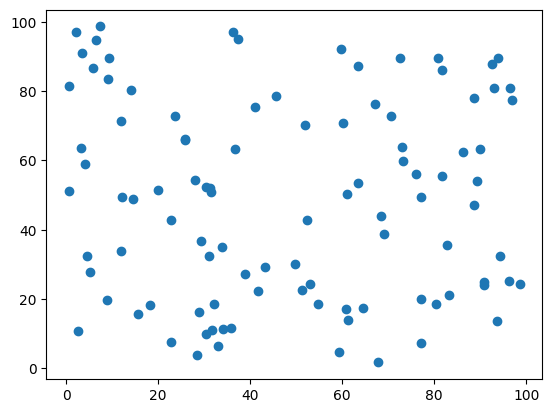

In [264]:
def euclidean_distance_matrix_manual(points):
    n = len(points)
    dist_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            diff_x = points[i, 0] - points[j, 0]
            diff_y = points[i, 1] - points[j, 1]
            dist_matrix[i, j] = np.sqrt(diff_x**2 + diff_y**2)
    
    return dist_matrix

def euclidean_distance_matrix_numpy(points):
    diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
    dist_matrix = np.sqrt(np.sum(diff**2, axis=2))
    return dist_matrix

np.random.seed(42)
points = np.random.rand(100, 2) * 100
dist_matrix_manual = euclidean_distance_matrix_manual(points)
print(dist_matrix_manual)
plt.scatter(points[:,0], points[:,1])


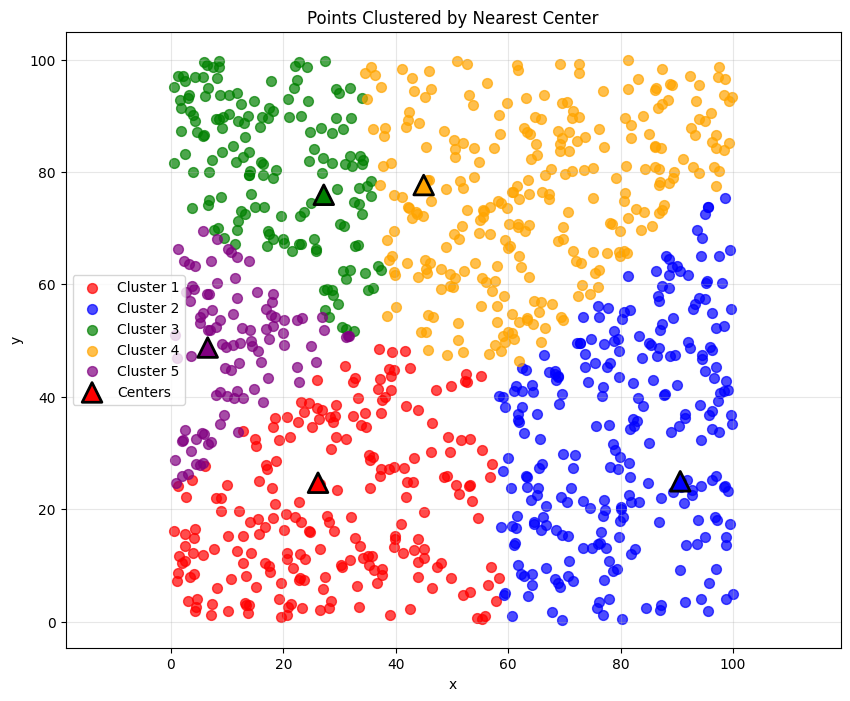

In [265]:
# 5

np.random.seed(42)
x = np.random.rand(1000, 2) * 100
c = np.random.rand(5, 2) * 100

def calculate_distances(x, c):
    n = len(x)
    m = len(c)
    dist = np.zeros((n, m))
    
    for i in range(n):
        for j in range(m):
            dx = x[i, 0] - c[j, 0]
            dy = x[i, 1] - c[j, 1]
            dist[i, j] = np.sqrt(dx**2 + dy**2)
    
    return dist

dist_matrix = calculate_distances(x, c)
nearest = np.argmin(dist_matrix, axis=1)

# Colors for each cluster
colors = ['red', 'blue', 'green', 'orange', 'purple']
point_colors = [colors[i] for i in nearest]

# Plot
plt.figure(figsize=(10, 8))

# Plot points
for i in range(5):
    mask = nearest == i
    plt.scatter(x[mask, 0], x[mask, 1], c=colors[i], s=50, alpha=0.7, label=f'Cluster {i+1}')

# Plot centers
plt.scatter(c[:, 0], c[:, 1], c=colors, marker='^', s=200, edgecolors='black', 
           linewidths=2, label='Centers')


plt.title('Points Clustered by Nearest Center')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()